In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import entropy
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RCP_PATH = "rcp_trump_approval.csv"
JAN1_PATH = "kalshi-price-history-kxaprpotuseoy-26jan01-minute.csv"
JAN9_PATH = "kalshi-price-history-kxaprpotus-26jan09-minute.csv"
JAN30_PATH = "kalshi-price-history-kxaprpotus-26jan30-minute.csv"
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [29]:
# load rcp polling
rcp = pd.read_csv(RCP_PATH)
rcp['date'] = pd.to_datetime(rcp['date'], format='mixed', dayfirst=False)
for col in ['approve', 'disapprove']:
    if rcp[col].dtype == object:
        rcp[col] = rcp[col].str.replace('%', '').astype(float)
rcp = rcp.sort_values('date').reset_index(drop=True)
rcp['net_approval'] = rcp['approve'] - rcp['disapprove']
rcp['approve_delta'] = rcp['approve'].diff()

print(f"RCP: {len(rcp)} rows, {rcp['date'].min().date()} to {rcp['date'].max().date()}")
print(f"Approval: {rcp['approve'].max():.1f}% -> {rcp['approve'].min():.1f}% ({rcp['approve'].max() - rcp['approve'].min():.1f}pp swing)")
rcp.head(15)

RCP: 376 rows, 2025-01-27 to 2026-02-06
Approval: 50.5% -> 42.2% (8.3pp swing)


,date,approve,disapprove,net_approval,approve_delta
0,2025-01-27,50.5,44.3,6.2,NaN
1,2025-01-28,50.4,44.5,5.9,-0.1
2,2025-01-29,50.3,44.8,5.5,-0.1
3,2025-01-30,50.2,44.6,5.6,-0.1
4,2025-01-31,49.9,44.7,5.2,-0.3
5,2025-02-01,49.9,44.7,5.2,0.0
6,2025-02-02,49.6,44.6,5.0,-0.3
7,2025-02-03,49.4,44.8,4.6,-0.2
8,2025-02-04,49.2,44.8,4.4,-0.2
9,2025-02-05,49.0,44.9,4.1,-0.2


In [30]:
# load kalshi markets
def load_kalshi(path):
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.fillna(0)
    return df

jan1 = load_kalshi(JAN1_PATH)
jan9 = load_kalshi(JAN9_PATH)
jan30 = load_kalshi(JAN30_PATH)

for name, df in [("Jan1", jan1), ("Jan9", jan9), ("Jan30", jan30)]:
    bucket_cols = [c for c in df.columns if c != 'timestamp']
    print(f"{name}: {len(df)} ticks, {len(bucket_cols)} buckets, spans {df['timestamp'].max() - df['timestamp'].min()}")

Jan1: 5466 ticks, 12 buckets, spans 105 days 10:51:00
Jan9: 2524 ticks, 8 buckets, spans 6 days 20:18:00
Jan30: 726 ticks, 8 buckets, spans 6 days 10:56:00


In [31]:
# parse bucket column names into midpoints (e.g. "42.0 to 42.9" -> 42.45)
def guess_midpoint(col_name):
    col = col_name.strip()
    if 'or below' in col.lower():
        return float(col.lower().replace('or below', '').strip()) - 0.45
    elif 'or above' in col.lower():
        return float(col.lower().replace('or above', '').strip()) + 0.45
    elif ' to ' in col:
        parts = col.split(' to ')
        return (float(parts[0].strip()) + float(parts[1].strip())) / 2
    return None

def build_midpoints(df):
    midpoints = {}
    for col in [c for c in df.columns if c != 'timestamp']:
        mid = guess_midpoint(col)
        if mid is not None:
            midpoints[col] = mid
        else:
            print(f"  WARNING: couldn't parse '{col}'")
    return midpoints

jan1_midpoints = build_midpoints(jan1)
jan9_midpoints = build_midpoints(jan9)
jan30_midpoints = build_midpoints(jan30)

for name, mp in [("Jan1", jan1_midpoints), ("Jan9", jan9_midpoints), ("Jan30", jan30_midpoints)]:
    vals = list(mp.values())
    width = np.mean(np.diff(sorted(vals))) if len(vals) > 1 else 0
    print(f"{name}: {len(mp)} buckets, ~{width:.2f}pp wide, range [{min(vals):.1f}, {max(vals):.1f}]")

Jan1: 12 buckets, ~1.01pp wide, range [39.4, 50.6]
Jan9: 8 buckets, ~0.49pp wide, range [41.4, 44.9]
Jan30: 8 buckets, ~0.40pp wide, range [41.4, 44.2]


In [32]:
# treat bucket prices as unnormalized probabilities, normalize,
# then get implied mean/median/mode/std/entropy
def compute_implied_stats(df, midpoints, timestamp_col='timestamp'):
    bucket_cols = [c for c in df.columns if c != timestamp_col]
    results = []

    for _, row in df.iterrows():
        prices = {midpoints[col]: row[col] for col in bucket_cols if col in midpoints}
        total = sum(prices.values())

        if total == 0:
            results.append({'timestamp': row[timestamp_col], 'implied_mean': np.nan,
                          'implied_median': np.nan, 'implied_mode': np.nan,
                          'total_probability': 0, 'n_active_buckets': 0,
                          'shannon_entropy': np.nan, 'implied_std': np.nan})
            continue

        probs = {k: v / total for k, v in prices.items()}
        implied_mean = sum(k * v for k, v in probs.items())
        implied_var = sum(v * (k - implied_mean) ** 2 for k, v in probs.items())
        implied_mode = max(probs, key=probs.get)

        sorted_items = sorted(probs.items())
        cumulative = 0
        implied_median = sorted_items[0][0]
        for midpoint, prob in sorted_items:
            cumulative += prob
            if cumulative >= 0.5:
                implied_median = midpoint
                break

        prob_array = np.array([v for v in probs.values() if v > 0])

        results.append({
            'timestamp': row[timestamp_col], 'implied_mean': implied_mean,
            'implied_median': implied_median, 'implied_mode': implied_mode,
            'total_probability': total, 'n_active_buckets': sum(1 for v in prices.values() if v > 0),
            'shannon_entropy': entropy(prob_array), 'implied_std': np.sqrt(implied_var)
        })

    return pd.DataFrame(results)

jan1_stats = compute_implied_stats(jan1, jan1_midpoints)
jan9_stats = compute_implied_stats(jan9, jan9_midpoints)
jan30_stats = compute_implied_stats(jan30, jan30_midpoints)

for name, s in [("Jan1", jan1_stats), ("Jan9", jan9_stats), ("Jan30", jan30_stats)]:
    print(f"{name}: mean {s['implied_mean'].min():.2f}-{s['implied_mean'].max():.2f}, "
          f"std {s['implied_std'].mean():.2f}, entropy {s['shannon_entropy'].mean():.2f}")

Jan1: mean 41.78-45.20, std 2.36, entropy 1.77
Jan9: mean 42.74-44.44, std 0.82, entropy 1.58
Jan30: mean 41.45-43.20, std 0.49, entropy 1.53


In [33]:
# forward-fill to 1-min grid to see how long the market sat at each level
def resample_kalshi(df, midpoints, freq='1min'):
    df_indexed = df.set_index('timestamp')
    full_range = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq=freq)
    resampled = df_indexed.reindex(full_range, method='ffill')
    resampled.index.name = 'timestamp'
    return compute_implied_stats(resampled.reset_index(), midpoints)

jan1_resampled = resample_kalshi(jan1, jan1_midpoints)
jan9_resampled = resample_kalshi(jan9, jan9_midpoints)
jan30_resampled = resample_kalshi(jan30, jan30_midpoints)

for name, raw, res in [("Jan1", jan1, jan1_resampled), ("Jan9", jan9, jan9_resampled), ("Jan30", jan30, jan30_resampled)]:
    print(f"{name}: {len(raw)} trades -> {len(res)} minutes")

Jan1: 5466 trades -> 151852 minutes
Jan9: 2524 trades -> 9859 minutes
Jan30: 726 trades -> 9297 minutes


In [34]:
# detect jumps across ALL markets, export a clean table
def detect_jumps(stats_df, col='implied_mean', threshold=0.5):
    df = stats_df.dropna(subset=[col]).copy()
    df['change'] = df[col].diff()
    df['pct_change'] = df[col].pct_change() * 100
    df['time_gap'] = df['timestamp'].diff()
    df['total_prob'] = df['total_probability']
    return df[df['change'].abs() > threshold][[
        'timestamp', col, 'change', 'pct_change', 'time_gap', 'total_prob',
        'implied_std', 'shannon_entropy', 'n_active_buckets'
    ]]

all_jump_rows = []
for name, s in [("jan1", jan1_stats), ("jan9", jan9_stats), ("jan30", jan30_stats)]:
    jumps = detect_jumps(s, threshold=0.5)
    jumps = jumps.copy()
    jumps['market'] = name
    jumps['direction'] = jumps['change'].apply(lambda x: 'up' if x > 0 else 'down')
    jumps['abs_change'] = jumps['change'].abs()
    all_jump_rows.append(jumps)

all_jumps_df = pd.concat(all_jump_rows, ignore_index=True)
all_jumps_df = all_jumps_df.sort_values('abs_change', ascending=False)

print(f"Found {len(all_jumps_df)} jumps across all markets (threshold=0.5pp)\n")
print(all_jumps_df[['market', 'timestamp', 'direction', 'change', 'implied_mean',
                     'total_prob', 'time_gap']].to_string(index=False))

all_jumps_df.to_csv(f'{OUTPUT_DIR}/all_jumps.csv', index=False)
print(f"\nSaved to {OUTPUT_DIR}/all_jumps.csv")

Found 5 jumps across all markets (threshold=0.5pp)

market                 timestamp direction    change  implied_mean  total_prob        time_gap
 jan30 2026-01-24 11:05:00+00:00        up  1.668449     43.118449       10.19 0 days 06:01:00
  jan1 2025-09-23 14:53:00+00:00        up  1.631196     44.874761       60.74 0 days 22:54:00
  jan1 2025-09-18 14:49:00+00:00        up  1.496644     43.946644       23.84 0 days 09:40:00
  jan1 2025-11-04 15:00:00+00:00      down -0.695134     43.822761      134.00 0 days 00:36:00
  jan1 2025-09-19 17:14:00+00:00      down -0.502606     43.444039       26.84 1 days 02:25:00

Saved to plots/all_jumps.csv


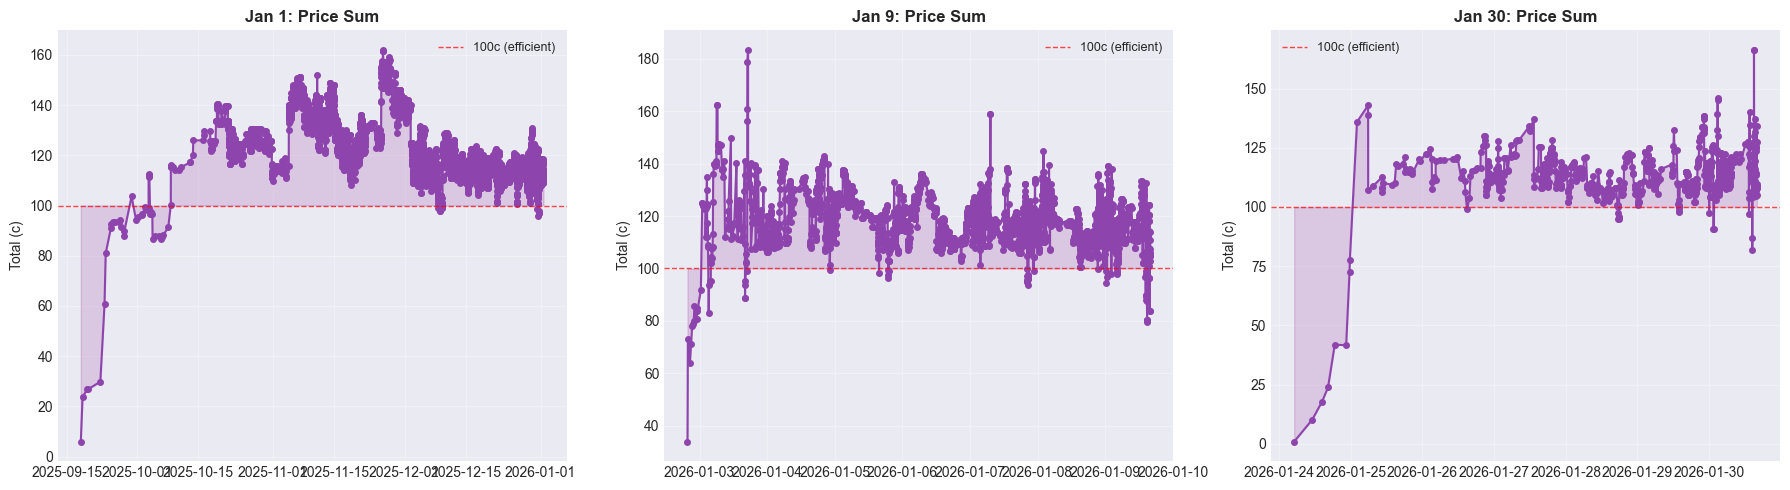

In [35]:
# price efficiency: bucket prices should sum to ~100 in an efficient market
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, s) in zip(axes, [("Jan 1", jan1_stats), ("Jan 9", jan9_stats), ("Jan 30", jan30_stats)]):
    ax.plot(s['timestamp'], s['total_probability'], 'o-', ms=4, lw=1.5, color='#8e44ad')
    ax.axhline(100, color='red', ls='--', lw=1, alpha=0.7, label='100c (efficient)')
    ax.fill_between(s['timestamp'], s['total_probability'], 100, alpha=0.15, color='purple')
    ax.set_title(f'{name}: Price Sum', fontweight='bold')
    ax.set_ylabel('Total (c)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/00_price_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

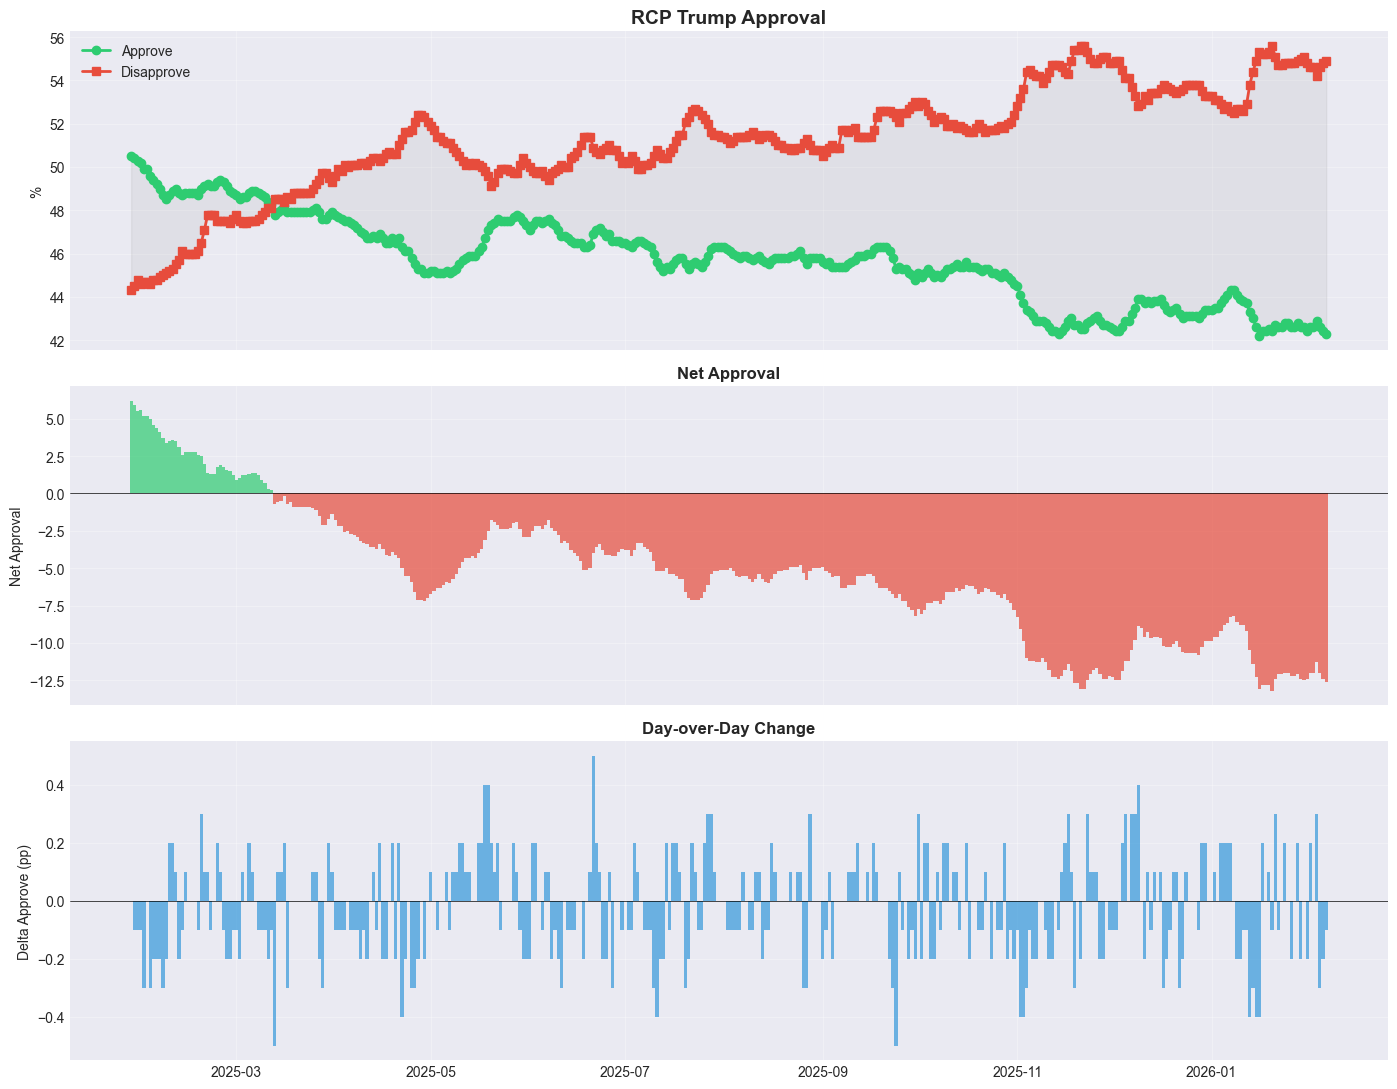

In [36]:
# rcp approval + net approval + daily delta
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(rcp['date'], rcp['approve'], 'o-', color='#2ecc71', lw=2, ms=6, label='Approve')
axes[0].plot(rcp['date'], rcp['disapprove'], 's-', color='#e74c3c', lw=2, ms=6, label='Disapprove')
axes[0].fill_between(rcp['date'], rcp['approve'], rcp['disapprove'], alpha=0.1, color='gray')
axes[0].set_ylabel('%')
axes[0].set_title('RCP Trump Approval', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in rcp['net_approval']]
axes[1].bar(rcp['date'], rcp['net_approval'], color=colors, alpha=0.7, width=1)
axes[1].axhline(y=0, color='black', lw=0.5)
axes[1].set_ylabel('Net Approval')
axes[1].set_title('Net Approval', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].bar(rcp['date'], rcp['approve_delta'], color='#3498db', alpha=0.7, width=1)
axes[2].axhline(y=0, color='black', lw=0.5)
axes[2].set_ylabel('Delta Approve (pp)')
axes[2].set_title('Day-over-Day Change', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_rcp_polling.png', dpi=150, bbox_inches='tight')
plt.show()

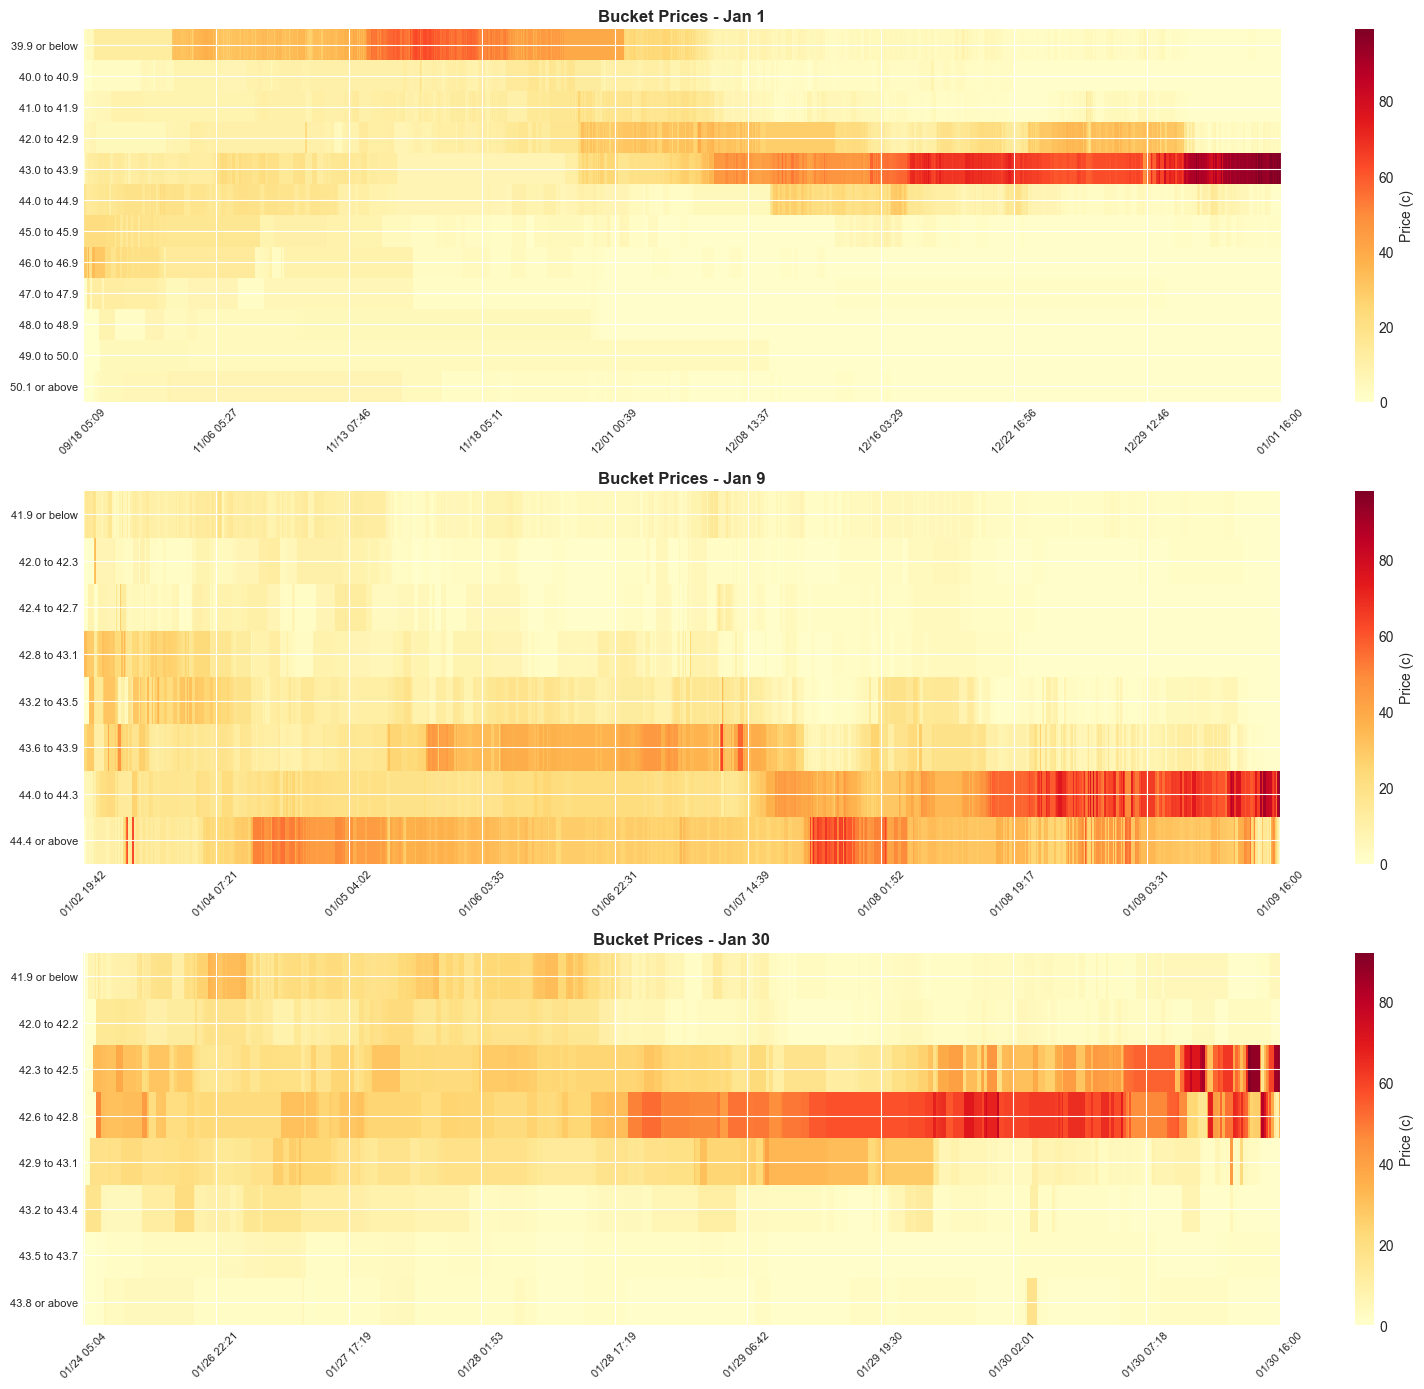

In [37]:
# bucket price heatmaps
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, (name, df) in zip(axes, [("Jan 1", jan1), ("Jan 9", jan9), ("Jan 30", jan30)]):
    bucket_cols = [c for c in df.columns if c != 'timestamp']
    im = ax.imshow(df[bucket_cols].values.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_yticks(range(len(bucket_cols)))
    ax.set_yticklabels(bucket_cols, fontsize=8)
    n_ticks = min(10, len(df))
    tick_locs = np.linspace(0, len(df) - 1, n_ticks, dtype=int)
    ax.set_xticks(tick_locs)
    ax.set_xticklabels([df['timestamp'].iloc[i].strftime('%m/%d %H:%M') for i in tick_locs], rotation=45, fontsize=8)
    ax.set_title(f'Bucket Prices - {name}', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Price (c)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_kalshi_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

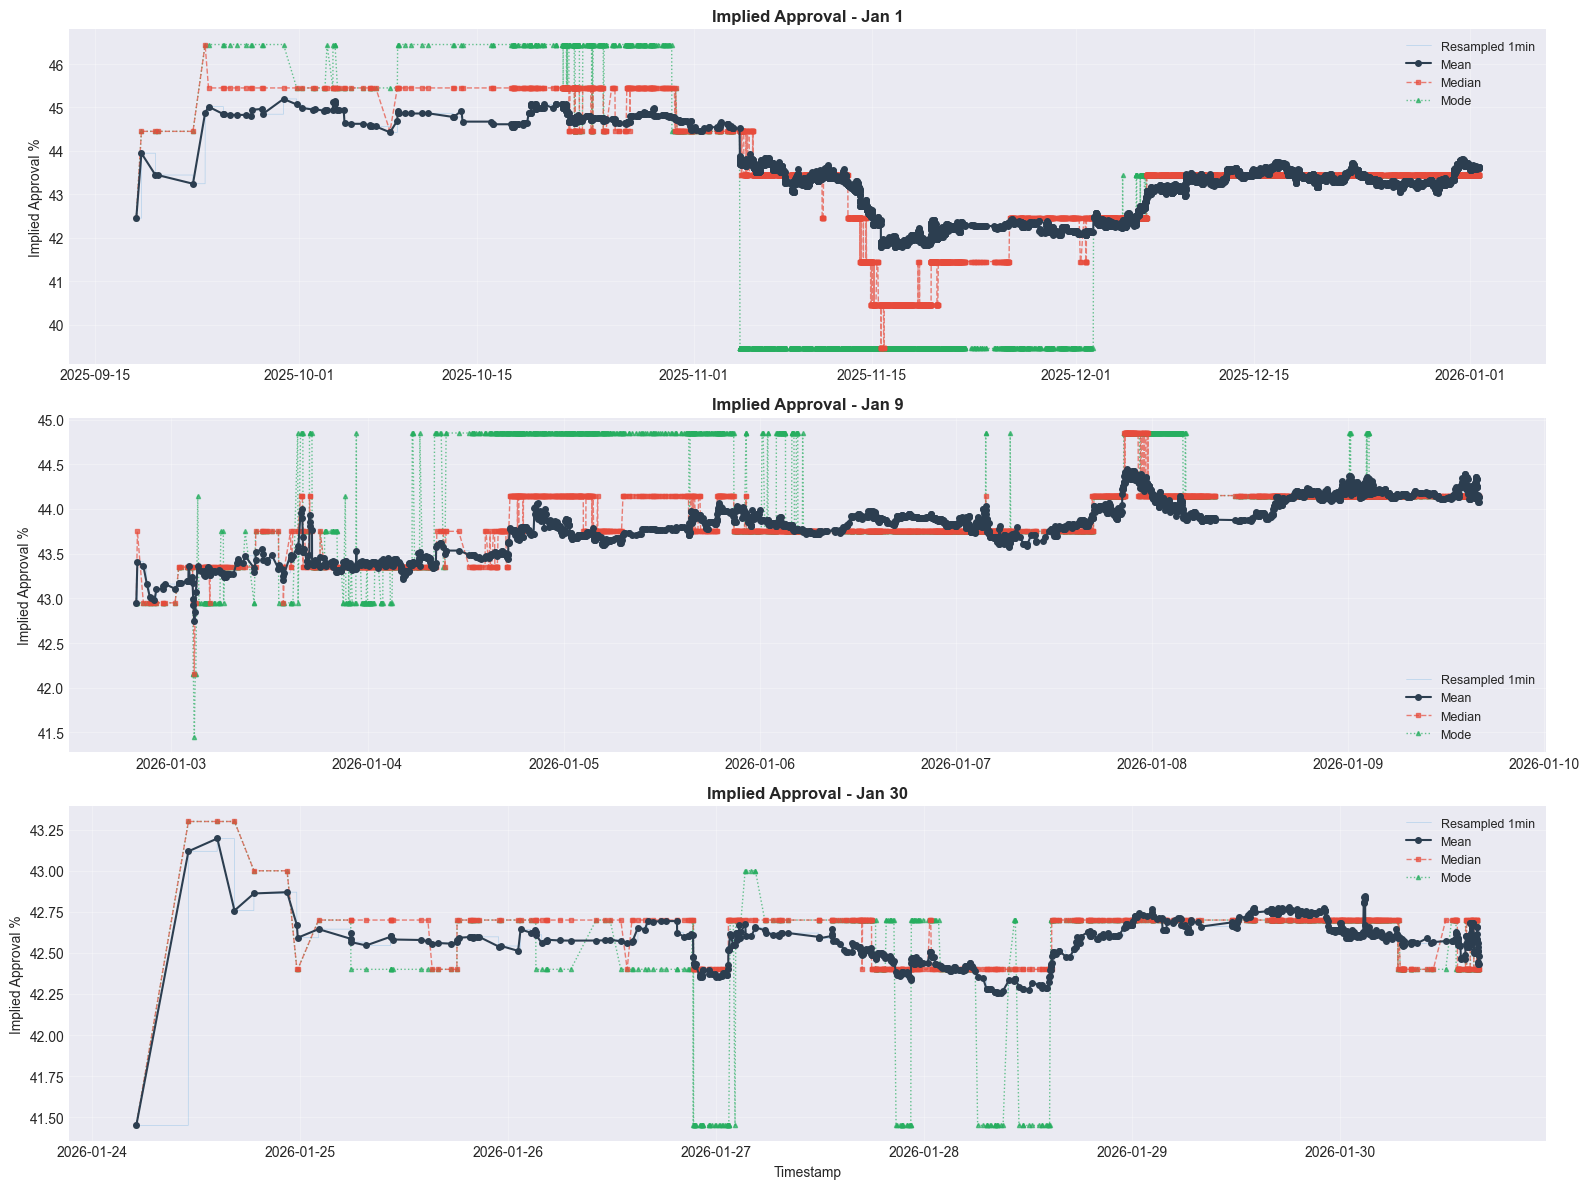

In [38]:
# implied mean/median/mode with resampled 1-min curve underneath
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (name, raw_s, res) in zip(axes, [
    ("Jan 1", jan1_stats, jan1_resampled),
    ("Jan 9", jan9_stats, jan9_resampled),
    ("Jan 30", jan30_stats, jan30_resampled)
]):
    ax.plot(res['timestamp'], res['implied_mean'], '-', color='#3498db', alpha=0.3, lw=0.5, label='Resampled 1min')
    ax.plot(raw_s['timestamp'], raw_s['implied_mean'], 'o-', color='#2c3e50', lw=1.5, ms=4, label='Mean', zorder=5)
    ax.plot(raw_s['timestamp'], raw_s['implied_median'], 's--', color='#e74c3c', lw=1, ms=3, label='Median', alpha=0.7, zorder=4)
    ax.plot(raw_s['timestamp'], raw_s['implied_mode'], '^:', color='#27ae60', lw=1, ms=3, label='Mode', alpha=0.7, zorder=3)
    ax.set_ylabel('Implied Approval %')
    ax.set_title(f'Implied Approval - {name}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_implied_stats.png', dpi=150, bbox_inches='tight')
plt.show()

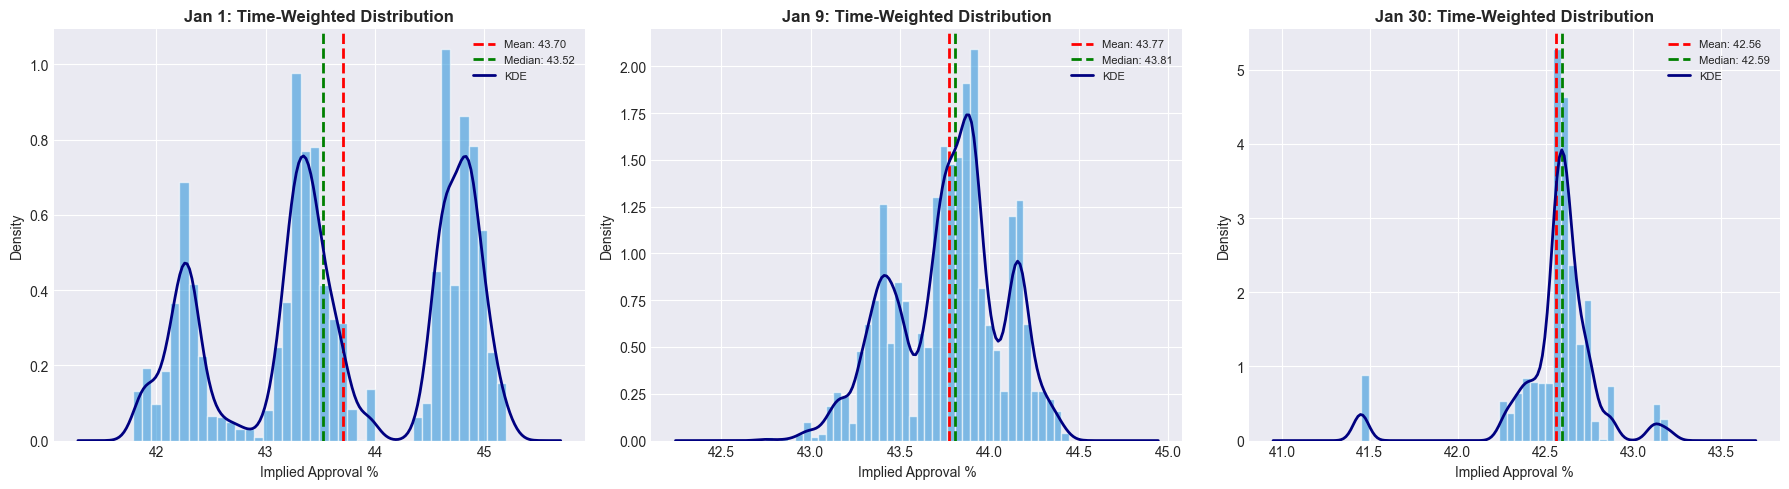

In [39]:
# time-weighted distribution of implied mean + KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, [("Jan 1", jan1_resampled), ("Jan 9", jan9_resampled), ("Jan 30", jan30_resampled)]):
    data = res['implied_mean'].dropna()
    ax.hist(data, bins=40, alpha=0.6, color='#3498db', edgecolor='white', density=True)
    ax.axvline(data.mean(), color='red', ls='--', lw=2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', ls='--', lw=2, label=f'Median: {data.median():.2f}')
    if len(data.unique()) > 2:
        kde_x = np.linspace(data.min() - 0.5, data.max() + 0.5, 200)
        ax.plot(kde_x, stats.gaussian_kde(data)(kde_x), color='navy', lw=2, label='KDE')
    ax.set_title(f'{name}: Time-Weighted Distribution', fontweight='bold')
    ax.set_xlabel('Implied Approval %')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_resampled_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

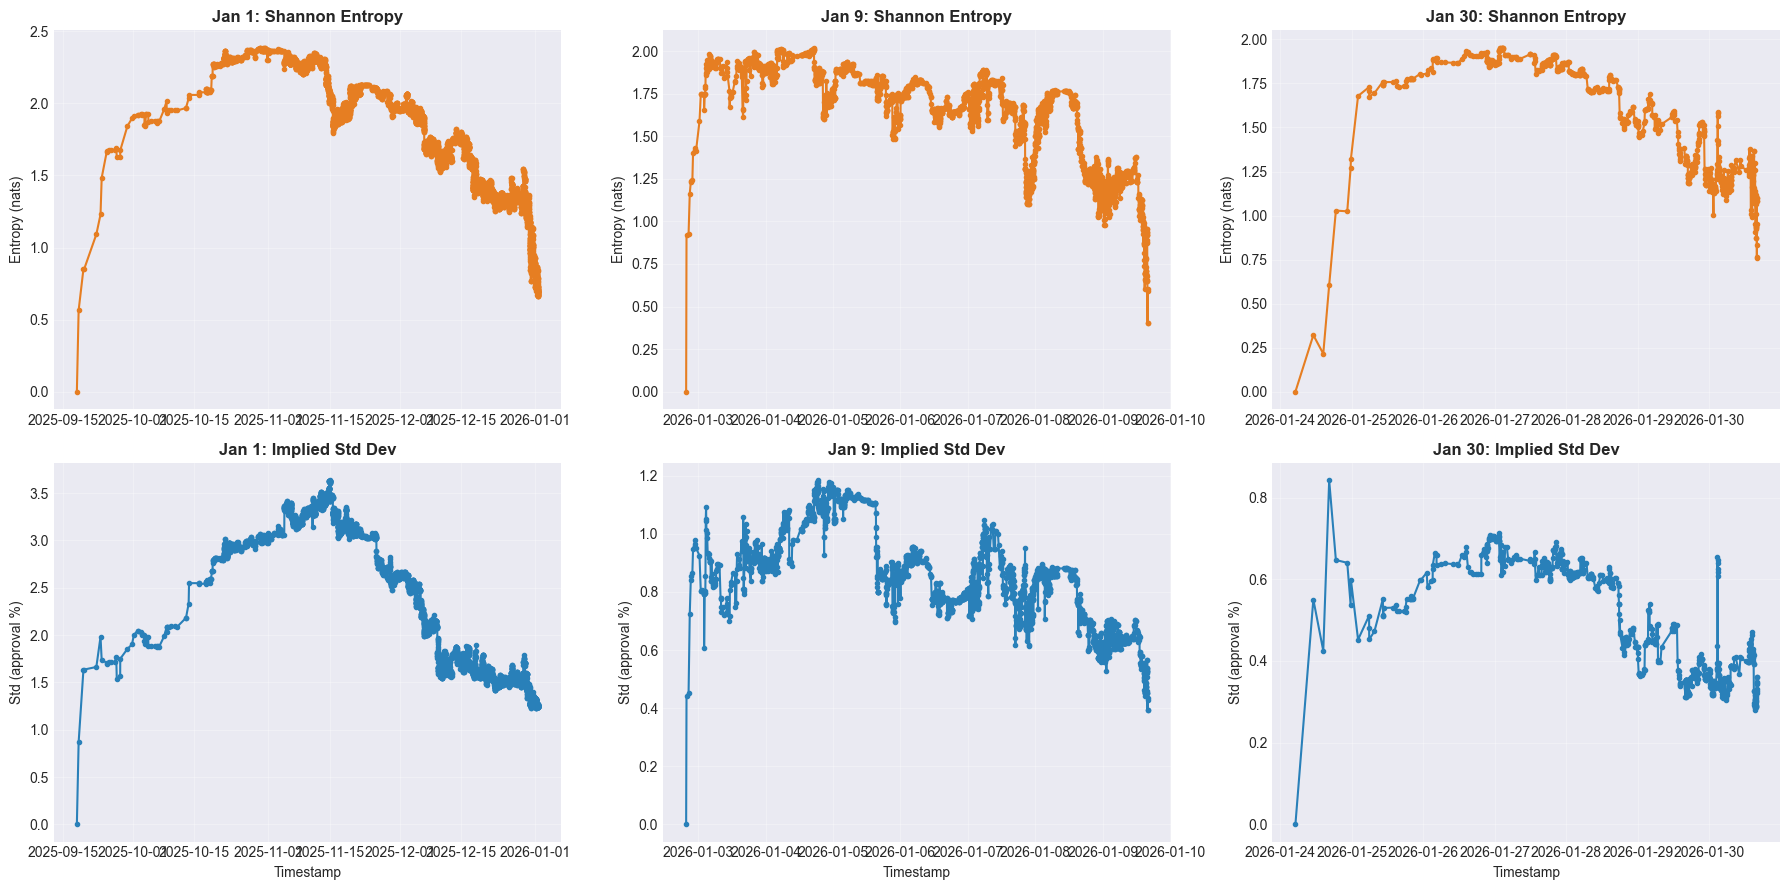

In [40]:
# uncertainty over time: entropy (how unsure) and std (how spread)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col_idx, (name, s) in enumerate([("Jan 1", jan1_stats), ("Jan 9", jan9_stats), ("Jan 30", jan30_stats)]):
    axes[0, col_idx].plot(s['timestamp'], s['shannon_entropy'], 'o-', color='#e67e22', ms=3, lw=1.5)
    axes[0, col_idx].set_title(f'{name}: Shannon Entropy', fontweight='bold')
    axes[0, col_idx].set_ylabel('Entropy (nats)')
    axes[0, col_idx].grid(True, alpha=0.3)

    axes[1, col_idx].plot(s['timestamp'], s['implied_std'], 'o-', color='#2980b9', ms=3, lw=1.5)
    axes[1, col_idx].set_title(f'{name}: Implied Std Dev', fontweight='bold')
    axes[1, col_idx].set_ylabel('Std (approval %)')
    axes[1, col_idx].set_xlabel('Timestamp')
    axes[1, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

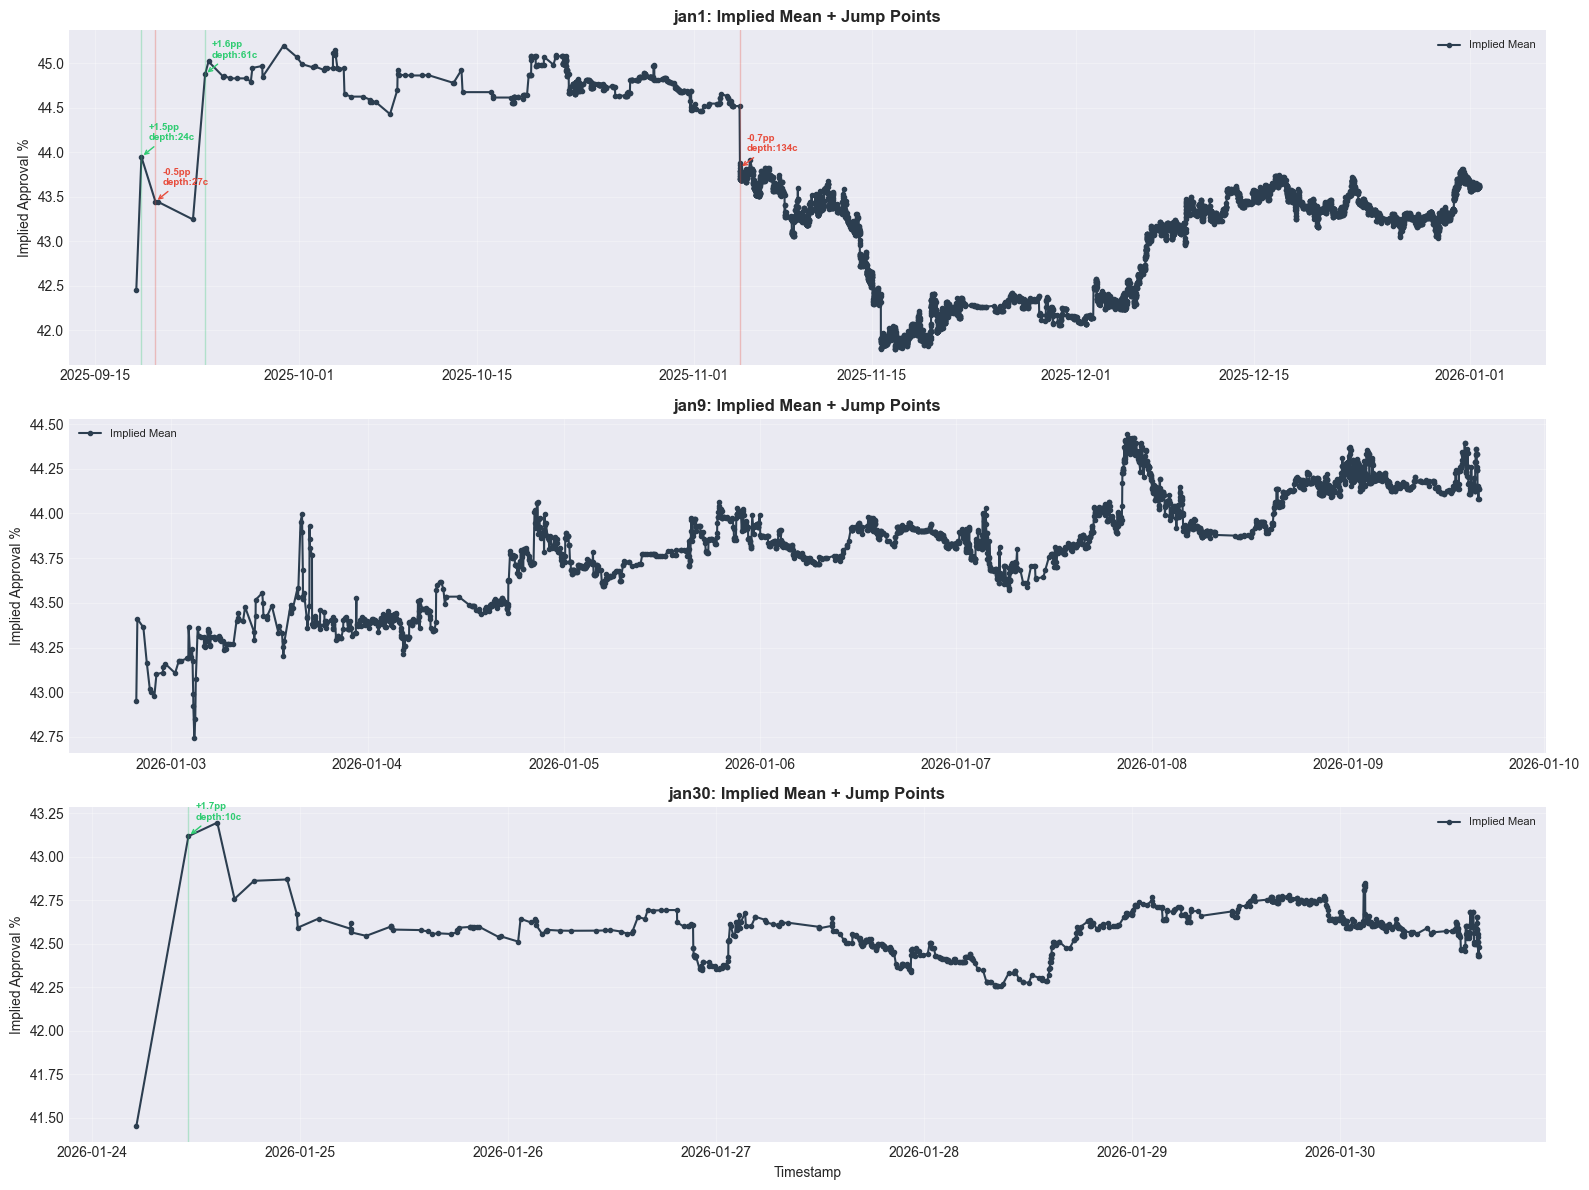

In [41]:
# per-market jump timelines with depth context
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (name, s) in zip(axes, [("jan1", jan1_stats), ("jan9", jan9_stats), ("jan30", jan30_stats)]):
    ax.plot(s['timestamp'], s['implied_mean'], 'o-', color='#2c3e50', lw=1.5, ms=3, label='Implied Mean')

    market_jumps = all_jumps_df[all_jumps_df['market'] == name]
    for _, j in market_jumps.iterrows():
        c = '#e74c3c' if j['direction'] == 'down' else '#2ecc71'
        ax.axvline(j['timestamp'], color=c, alpha=0.3, lw=1)
        ax.annotate(f"{j['change']:+.1f}pp\ndepth:{j['total_prob']:.0f}c",
                    xy=(j['timestamp'], j['implied_mean']),
                    fontsize=7, fontweight='bold', color=c,
                    xytext=(5, 12), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color=c), ha='left')

    ax.set_title(f'{name}: Implied Mean + Jump Points', fontweight='bold')
    ax.set_ylabel('Implied Approval %')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_jumps_per_market.png', dpi=150, bbox_inches='tight')
plt.show()

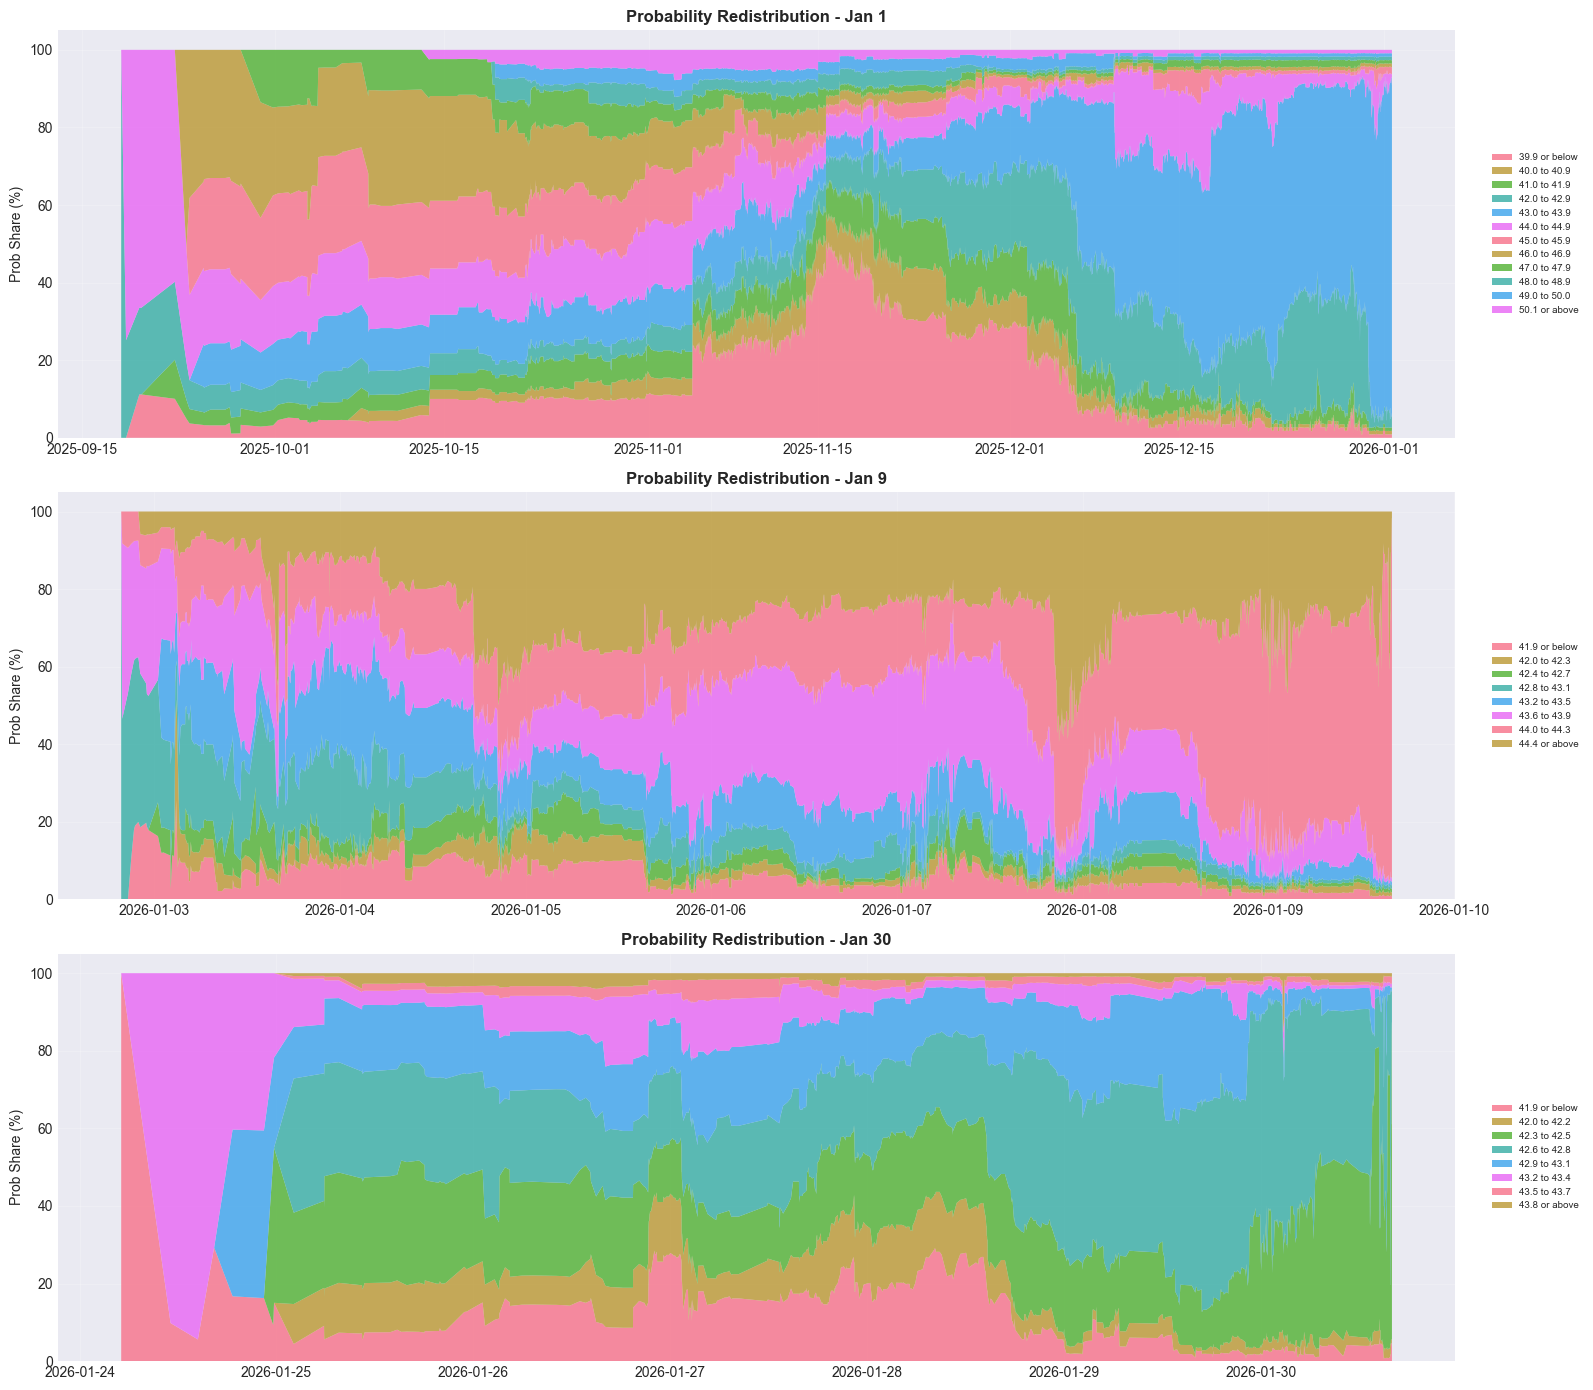

In [42]:
# stacked area: probability mass redistribution across buckets
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, (name, df) in zip(axes, [("Jan 1", jan1), ("Jan 9", jan9), ("Jan 30", jan30)]):
    bucket_cols = [c for c in df.columns if c != 'timestamp']
    row_sums = df[bucket_cols].sum(axis=1)
    norm = df[bucket_cols].div(row_sums, axis=0).fillna(0) * 100
    ax.stackplot(df['timestamp'], *[norm[col] for col in bucket_cols], labels=bucket_cols, alpha=0.8)
    ax.set_ylabel('Prob Share (%)')
    ax.set_title(f'Probability Redistribution - {name}', fontweight='bold')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_stacked_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

Jan 1: median gap 8min, mean 28min, max 66.7hrs
Jan 9: median gap 2min, mean 4min, max 2.4hrs
Jan 30: median gap 4min, mean 13min, max 6.0hrs


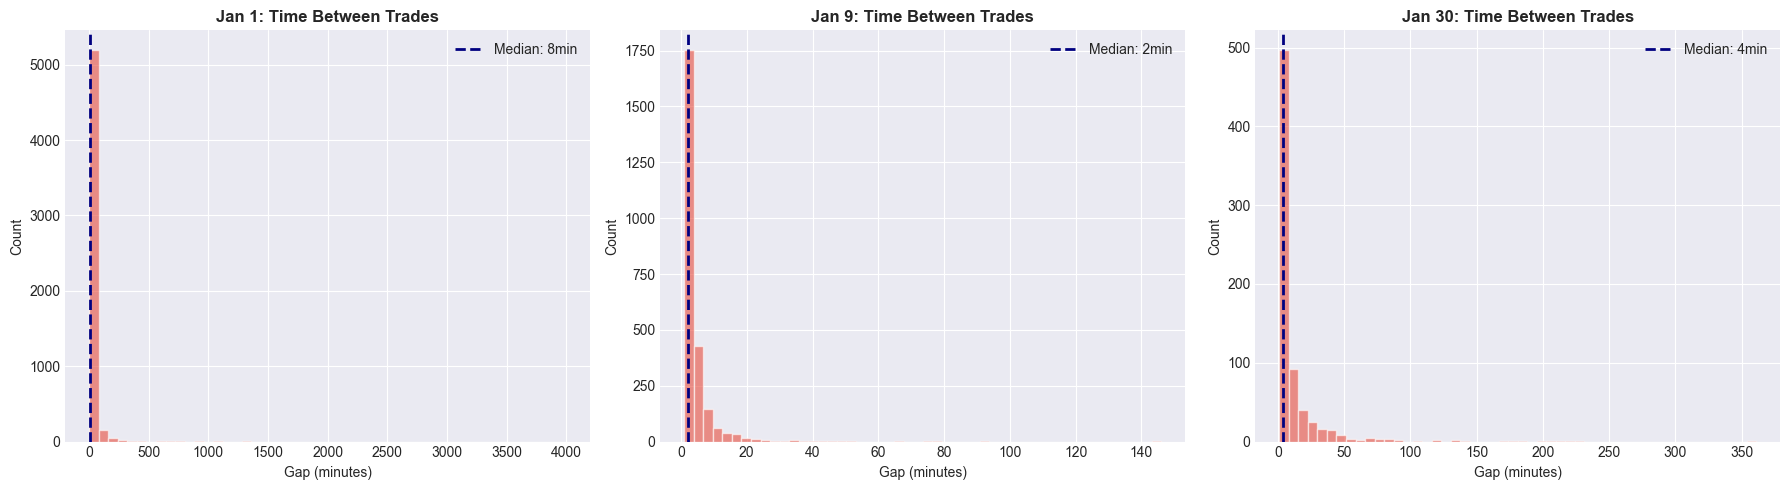

In [43]:
# inter-trade timing
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [("Jan 1", jan1), ("Jan 9", jan9), ("Jan 30", jan30)]):
    gaps = df['timestamp'].diff().dt.total_seconds() / 60
    gaps = gaps.dropna()
    ax.hist(gaps, bins=50, alpha=0.6, color='#e74c3c', edgecolor='white')
    ax.axvline(gaps.median(), color='navy', ls='--', lw=2, label=f'Median: {gaps.median():.0f}min')
    ax.set_title(f'{name}: Time Between Trades', fontweight='bold')
    ax.set_xlabel('Gap (minutes)')
    ax.set_ylabel('Count')
    ax.legend()
    print(f"{name}: median gap {gaps.median():.0f}min, mean {gaps.mean():.0f}min, max {gaps.max()/60:.1f}hrs")

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_trade_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

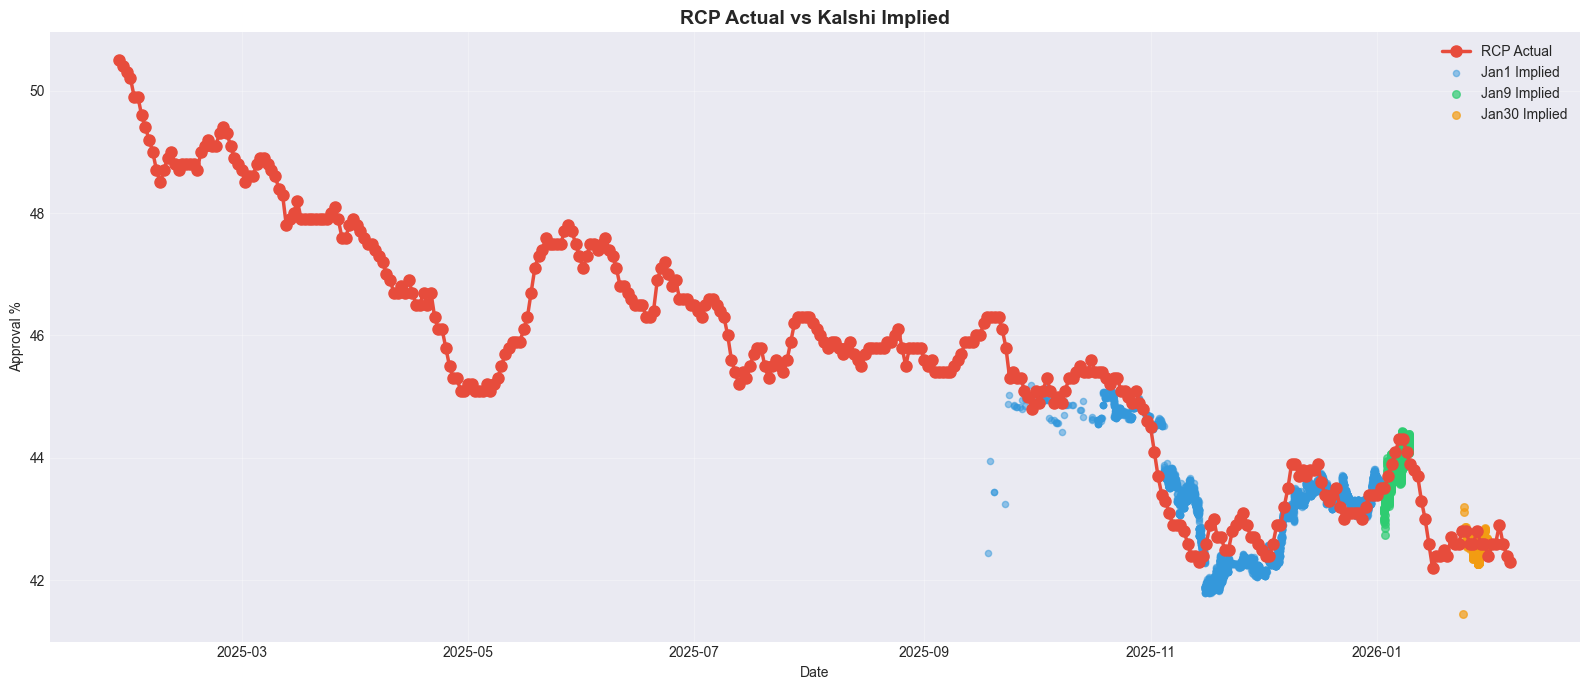

In [44]:
# rcp actual vs kalshi implied on one timeline
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(rcp['date'], rcp['approve'], 'o-', color='#e74c3c', lw=2.5, ms=8, label='RCP Actual', zorder=10)
ax.scatter(jan1_stats['timestamp'], jan1_stats['implied_mean'], c='#3498db', s=20, alpha=0.5, label='Jan1 Implied')
ax.scatter(jan9_stats['timestamp'], jan9_stats['implied_mean'], c='#2ecc71', s=30, alpha=0.7, label='Jan9 Implied')
ax.scatter(jan30_stats['timestamp'], jan30_stats['implied_mean'], c='#f39c12', s=30, alpha=0.7, label='Jan30 Implied')

ax.set_title('RCP Actual vs Kalshi Implied', fontsize=14, fontweight='bold')
ax.set_ylabel('Approval %')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_rcp_vs_kalshi.png', dpi=150, bbox_inches='tight')
plt.show()

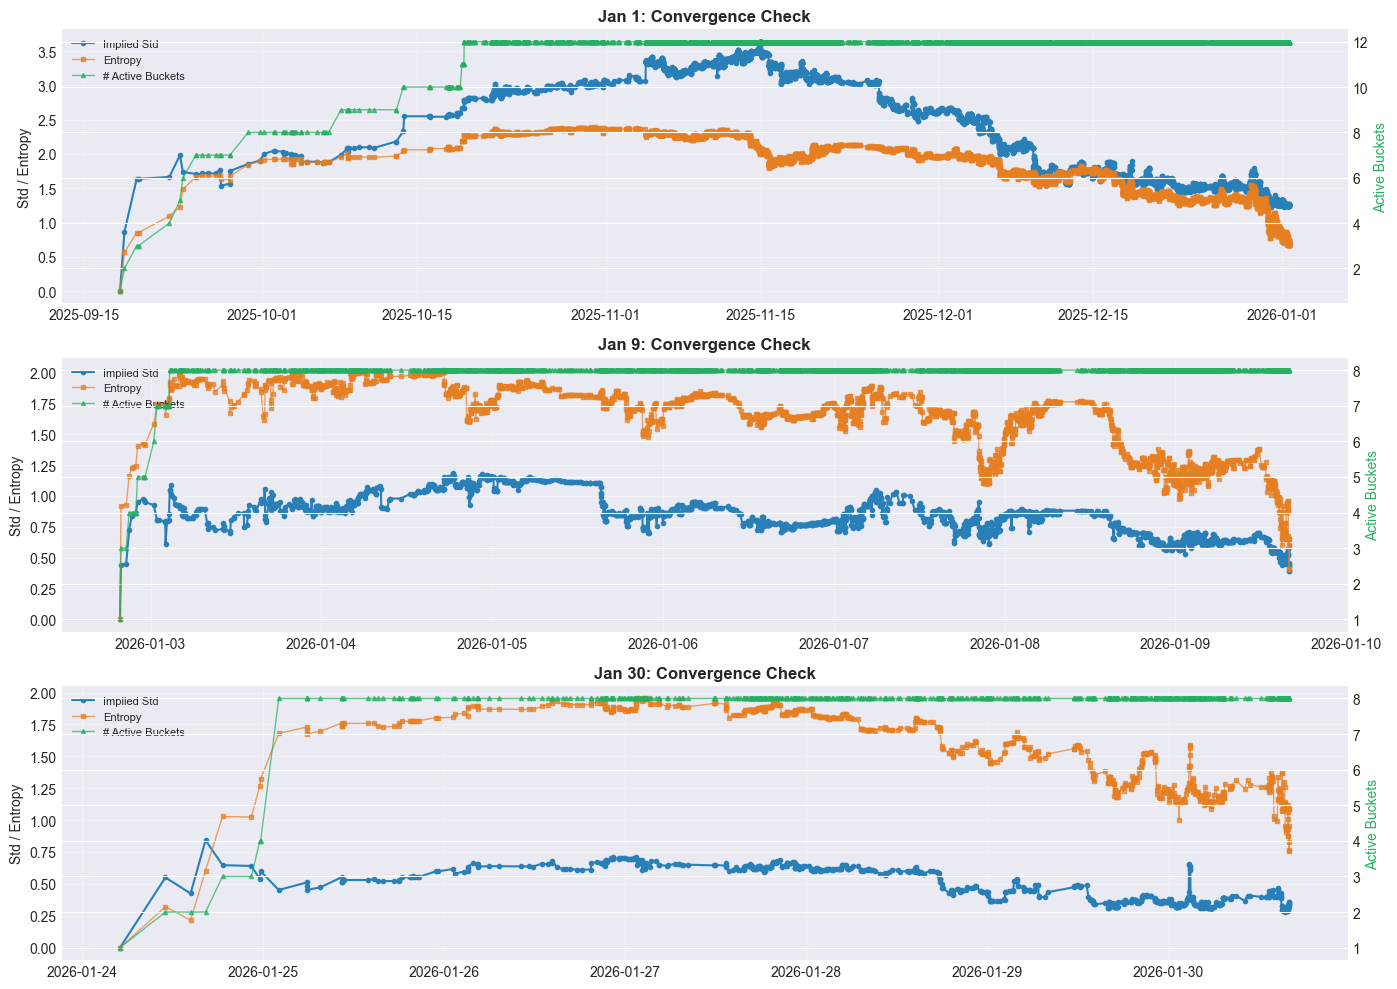

In [45]:
# convergence: does uncertainty decrease as resolution approaches?
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (name, s) in zip(axes, [("Jan 1", jan1_stats), ("Jan 9", jan9_stats), ("Jan 30", jan30_stats)]):
    ax2 = ax.twinx()
    ln1 = ax.plot(s['timestamp'], s['implied_std'], 'o-', color='#2980b9', ms=3, lw=1.5, label='Implied Std')
    ln2 = ax.plot(s['timestamp'], s['shannon_entropy'], 's-', color='#e67e22', ms=3, lw=1, alpha=0.7, label='Entropy')
    ln3 = ax2.plot(s['timestamp'], s['n_active_buckets'], '^-', color='#27ae60', ms=3, lw=1, alpha=0.7, label='# Active Buckets')
    ax.set_ylabel('Std / Entropy')
    ax2.set_ylabel('Active Buckets', color='#27ae60')
    ax.set_title(f'{name}: Convergence Check', fontweight='bold')
    lns = ln1 + ln2 + ln3
    ax.legend(lns, [l.get_label() for l in lns], fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# summary
print("--- RCP ---")
print(rcp[['approve', 'disapprove', 'net_approval']].describe().round(2))

for name, res in [("Jan1", jan1_resampled), ("Jan9", jan9_resampled), ("Jan30", jan30_resampled)]:
    print(f"\n--- {name} Resampled Implied Mean ---")
    print(res['implied_mean'].describe().round(2))

print("\n--- Final implied mean per market ---")
for name, s in [("Jan1", jan1_stats), ("Jan9", jan9_stats), ("Jan30", jan30_stats)]:
    print(f"  {name}: {s['implied_mean'].iloc[-1]:.2f}")

--- RCP ---
       approve  disapprove  net_approval
count   376.00      376.00        376.00
mean     45.73       51.22         -5.49
std       1.99        2.48          4.42
min      42.20       44.30        -13.20
25%      44.10       50.08         -8.62
50%      45.80       51.40         -5.50
75%      47.10       52.80         -2.90
max      50.50       55.60          6.20

--- Jan1 Resampled Implied Mean ---
count    151852.00
mean         43.70
std           1.00
min          41.78
25%          43.16
50%          43.52
75%          44.69
max          45.20
Name: implied_mean, dtype: float64

--- Jan9 Resampled Implied Mean ---
count    9859.00
mean       43.77
std         0.30
min        42.74
25%        43.53
50%        43.81
75%        43.95
max        44.44
Name: implied_mean, dtype: float64

--- Jan30 Resampled Implied Mean ---
count    9297.00
mean       42.56
std         0.27
min        41.45
25%        42.54
50%        42.59
75%        42.66
max        43.20
Name: implied

In [52]:
# jump table
print("=" * 80)
print("JUMP TABLE - what real-world events caused these")
print("=" * 80)
for _, row in all_jumps_df.iterrows():
    gap_hrs = row['time_gap'].total_seconds() / 3600 if pd.notna(row['time_gap']) else 0
    print(f"  Market: {row['market']} | {row['timestamp']} UTC | "
          f"{row['change']:+.2f}pp ({row['direction']}) | "
          f"implied mean -> {row['implied_mean']:.2f} | "
          f"depth: {row['total_prob']:.0f}c | gap: {gap_hrs:.1f}hrs")

JUMP TABLE - what real-world events caused these
  Market: jan30 | 2026-01-24 11:05:00+00:00 UTC | +1.67pp (up) | implied mean -> 43.12 | depth: 10c | gap: 6.0hrs
  Market: jan1 | 2025-09-23 14:53:00+00:00 UTC | +1.63pp (up) | implied mean -> 44.87 | depth: 61c | gap: 22.9hrs
  Market: jan1 | 2025-09-18 14:49:00+00:00 UTC | +1.50pp (up) | implied mean -> 43.95 | depth: 24c | gap: 9.7hrs
  Market: jan1 | 2025-11-04 15:00:00+00:00 UTC | -0.70pp (down) | implied mean -> 43.82 | depth: 134c | gap: 0.6hrs
  Market: jan1 | 2025-09-19 17:14:00+00:00 UTC | -0.50pp (down) | implied mean -> 43.44 | depth: 27c | gap: 26.4hrs
